In [70]:
# Tuodaan tarvittavat kirjastot
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import scipy.stats as stats

Siivotaan Fingridin data

In [71]:
#Tuodaan data ja katsotaan sarakkeet
df_electric = pd.read_json("Fingrid.json")
df_electric.head()

,datasetId,startTime,endTime,value
0,193,2025-12-31T21:51:00.000Z,2025-12-31T21:54:00.000Z,12368
1,193,2025-12-31T21:48:00.000Z,2025-12-31T21:51:00.000Z,12425
2,193,2025-12-31T21:45:00.000Z,2025-12-31T21:48:00.000Z,12455
3,193,2025-12-31T21:42:00.000Z,2025-12-31T21:45:00.000Z,12510
4,193,2025-12-31T21:39:00.000Z,2025-12-31T21:42:00.000Z,12540


In [72]:
#Muutetaan Päivämäärät ja luodaan yksi päivämäärä
df_electric["startTime"] = pd.to_datetime(df_electric["startTime"], utc=True)
df_electric["endTime"] = pd.to_datetime(df_electric["endTime"], utc=True)
df_electric["Date"] = (
    df_electric["startTime"]
    .dt.tz_convert("Europe/Helsinki")
    .dt.date
)

#Lasketaan MWh valuen perusteella
df_electric["MWh"] = df_electric["value"] * (3 / 60)

#Tehdään uusi dataframe, jossa yhdistetään MWh:t päivämäärä sarakkeeseen
daily = (
    df_electric.groupby("Date", as_index=False)
    .agg(MWh=("MWh", "sum"))
)
daily["Date"] = pd.to_datetime(daily["Date"])

#Lisätään GWh ja pudotetaan rivit ennen 2021-01-01 pois ja muutetaan desimaalit pois
daily["GWh"] = daily["MWh"] / 1000
daily = daily[daily["Date"] >= "2021-01-01"]
pd.options.display.float_format = '{:.0f}'.format

daily.head()

,Date,MWh,GWh
0,2021-01-01,234072,234
1,2021-01-02,238970,239
2,2021-01-03,240116,240
3,2021-01-04,263114,263
4,2021-01-05,274808,275


Siivotaan Säädata 

In [73]:
df_weather = pd.read_csv("Pirkkala_saa.csv")
df_weather.head()


,Havaintoasema,Vuosi,Kuukausi,Päivä,Aika [Paikallinen aika],Ilman keskilämpötila [°C]
0,Pirkkala Tampere-Pirkkala lentoasema,2021,1,1,02:00,-1
1,Pirkkala Tampere-Pirkkala lentoasema,2021,1,2,02:00,-2
2,Pirkkala Tampere-Pirkkala lentoasema,2021,1,3,02:00,-4
3,Pirkkala Tampere-Pirkkala lentoasema,2021,1,4,02:00,-4
4,Pirkkala Tampere-Pirkkala lentoasema,2021,1,5,02:00,-7


In [74]:
#Luodaan samanlainen Date sarake, kuin toisessa datasetissä ja pudetetaan turhat sarakkeet pois
df_weather["Date"] = df_weather["Vuosi"].astype(str) + "-" + df_weather["Kuukausi"].astype(str) + "-" + df_weather["Päivä"].astype(str)
df_weather["Date"] = pd.to_datetime(df_weather["Date"])
df_weather.drop(columns=["Vuosi", "Kuukausi", "Päivä", "Aika [Paikallinen aika]", "Havaintoasema"], inplace=True)
df_weather.head()

,Ilman keskilämpötila [°C],Date
0,-1,2021-01-01
1,-2,2021-01-02
2,-4,2021-01-03
3,-4,2021-01-04
4,-7,2021-01-05


Yhdistetään datasetit ja lisätään vuodenajat sarake

In [75]:
#Muutetaan indeksiksi sama Date sarake ja yhdistetään yhdeksi datasetiksi
daily.set_index("Date", inplace=True)
df_weather.set_index("Date", inplace=True)
df = daily.join(df_weather, how="outer").reset_index()
df.head()

,Date,MWh,GWh,Ilman keskilämpötila [°C]
0,2021-01-01,234072,234,-1
1,2021-01-02,238970,239,-2
2,2021-01-03,240116,240,-4
3,2021-01-04,263114,263,-4
4,2021-01-05,274808,275,-7


In [76]:
#Lisätään vuodenajat omaan sarakkeeseen
def seasons(month):
    if month in [12, 1, 2]:
        return "Talvi"
    elif month in [3, 4, 5]:
        return "Kevät"
    elif month in [6, 7, 8]:
        return "Kesä"
    else:
        return "Syksy"
    
df["Kuukausi"] = df["Date"].dt.month
df["Vuodenaika"] = df["Kuukausi"].apply(seasons)
df.head()

,Date,MWh,GWh,Ilman keskilämpötila [°C],Kuukausi,Vuodenaika
0,2021-01-01,234072,234,-1,1,Talvi
1,2021-01-02,238970,239,-2,1,Talvi
2,2021-01-03,240116,240,-4,1,Talvi
3,2021-01-04,263114,263,-4,1,Talvi
4,2021-01-05,274808,275,-7,1,Talvi


In [77]:
df.groupby("Vuodenaika")["GWh"].describe()

,count,mean,std,min,25%,50%,75%,max
Vuodenaika,,,,,,,,
Kesä,460,190,33,89,181,189,196,610
Kevät,460,231,47,166,204,224,245,535
Syksy,455,221,33,147,199,217,236,583
Talvi,451,299,96,219,251,268,289,651


Tehdään visualisoinnit

In [78]:
#Muutetaan datasettiä siten, että se ottaa huomioon vuodet ja kuukaudet
df["Vuosi"] = df["Date"].dt.year
df["MonthName"] = df["Date"].dt.month_name()
df["VuosiKuukausi"] = df["Date"].dt.to_period("M").dt.to_timestamp()

df.head()

,Date,MWh,GWh,Ilman keskilämpötila [°C],Kuukausi,Vuodenaika,Vuosi,MonthName,VuosiKuukausi
0,2021-01-01,234072,234,-1,1,Talvi,2021,January,2021-01-01
1,2021-01-02,238970,239,-2,1,Talvi,2021,January,2021-01-01
2,2021-01-03,240116,240,-4,1,Talvi,2021,January,2021-01-01
3,2021-01-04,263114,263,-4,1,Talvi,2021,January,2021-01-01
4,2021-01-05,274808,275,-7,1,Talvi,2021,January,2021-01-01


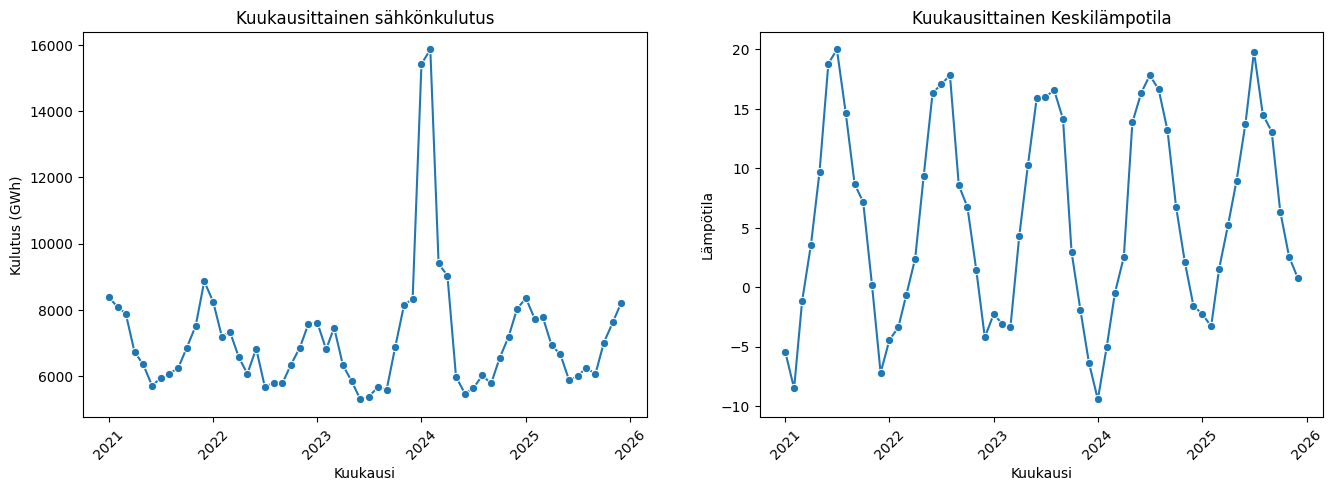

In [79]:
#Tehdään muuttuja ilman keskilämmölle ja tehdään Groupby kuukausittaisille katsaukselle vuosien yli. Käytetään sähkönkulutuksessa
#Kuukausittaista summaa ja lämpötilassa keskiarvoa
temperature = "Ilman keskilämpötila [°C]"
monthly = (df.groupby("VuosiKuukausi", as_index=False).agg({"GWh":"sum", temperature:"mean"}))

#Tehdään viivakaaviot molemmista
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
sns.lineplot(data=monthly, x="VuosiKuukausi", y="GWh", marker="o", ax=axes[0])
axes[0].set_title("Kuukausittainen sähkönkulutus")
axes[0].set_xlabel("Kuukausi")
axes[0].set_ylabel("Kulutus (GWh)")
axes[0].tick_params(axis="x", rotation=45)

sns.lineplot(data=monthly, x="VuosiKuukausi", y=temperature, marker="o", ax=axes[1])
axes[1].set_title("Kuukausittainen Keskilämpotila")
axes[1].set_xlabel("Kuukausi")
axes[1].set_ylabel("Lämpötila")
axes[1].tick_params(axis="x", rotation=45)

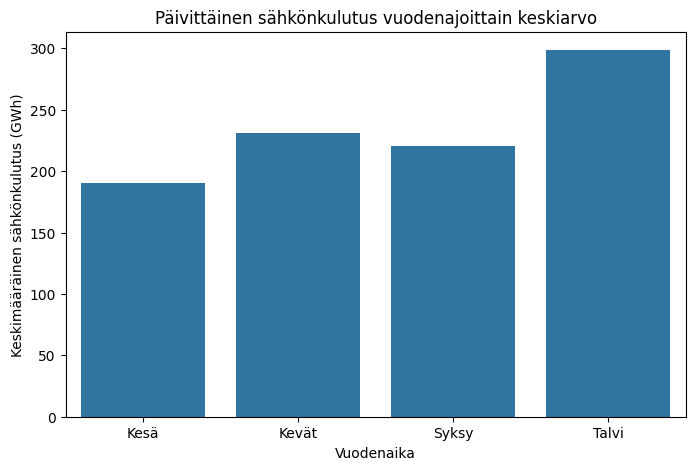

In [80]:
#Tehdään pylväskaavio, joka kuvaa vuodenaikojen vaikutusta sähkönkulutukseen
season_avg = (
    df.groupby("Vuodenaika", as_index=False)["GWh"]
      .mean()
)

plt.figure(figsize=(8, 5))
sns.barplot(data=season_avg, x="Vuodenaika", y="GWh")
plt.title("Päivittäinen sähkönkulutus vuodenajoittain keskiarvo")
plt.xlabel("Vuodenaika")
plt.ylabel("Keskimääräinen sähkönkulutus (GWh)")
plt.show()

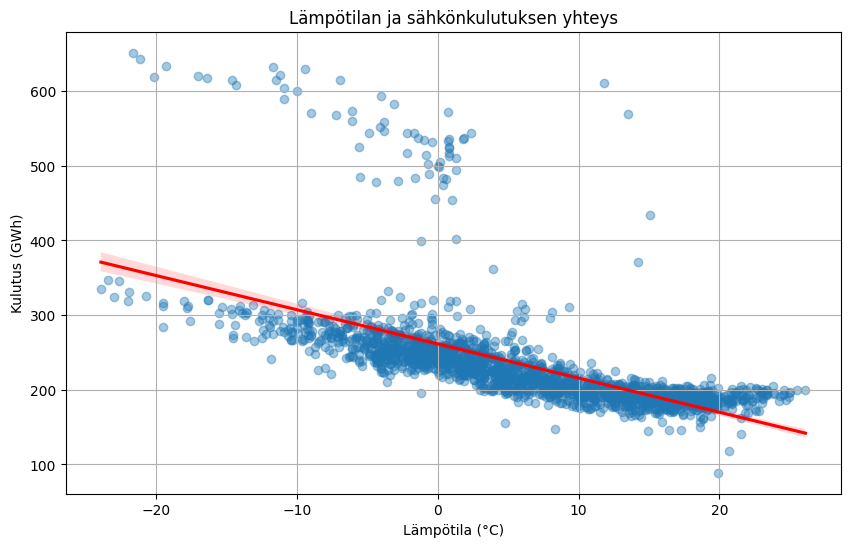

In [81]:
#Hajontakaavio Lämpötilan ja sähkönkulutuksen yhteydestä
plt.figure(figsize=(10, 6))

sns.regplot(data=df, x=temperature, y="GWh", scatter_kws={"alpha": 0.4}, line_kws={"color": "red"})
plt.title("Lämpötilan ja sähkönkulutuksen yhteys")
plt.xlabel("Lämpötila (°C)")
plt.ylabel("Kulutus (GWh)")
plt.grid(True)
plt.show()

In [82]:
#Korrelaatio lämpötilan ja sähkönkulutuksen välillä
corr = df[temperature].corr(df["GWh"])

print(f"Lämpötilan ja sähkönkulutuksen korrelaatiokerroin: {corr:.2f}")

Lämpötilan ja sähkönkulutuksen korrelaatiokerroin: -0.61


Tilastollinen testaus / Oletetaan, että talvella kulutus on suurempaa kuin kesällä

In [ ]:
#Tehdään datasetit talvelle ja katsotaan yleisesti, miltä tilastot vaikuttavat
talvi = df[df["Vuodenaika"] == "Talvi"]["GWh"]
kesa = df[df["Vuodenaika"] == "Kesä"]["GWh"]

yhteenveto = pd.DataFrame({
    "Ryhmä": ["Talvi", "Kesä"],
    "N" : [len(talvi), len(kesa)],
    "Keskiarvo": [round(talvi.mean(), 2), round(kesa.mean(), 2)],
    "Keskihajonta": [round(talvi.std(), 2), round(kesa.std(), 2)],
    "Keskiarvon keskivirhe": [round(talvi.sem(), 2), round(kesa.sem(), 2)]
})

print(yhteenveto.to_string(index=False))

Ryhmä   N  Keskiarvo  Keskihajonta  Keskiarvon keskivirhe
Talvi 451        299            96                      5
 Kesä 460        190            33                      2


In [90]:
#Tehdään Levenen testi 95% merkitsevyystasolla, jotta nähdään onko ryhmien varianssit yhtä suuret. Nollahypoteesi on,
#että varianssit ovat yhtä suuret
varianssi = stats.levene(talvi, kesa)
print(f"Levenen testi: W = {varianssi.statistic:.2f}, p = {varianssi.pvalue:.20f}")

Levenen testi: W = 72.43, p = 0.00000000000000007084


In [93]:
#Levenen testi osoitteaa, että variansseja ei voida olettaa yhtä suuriksi, jotan t-testissä käytetään euqual_var = False
t_stat, p_arvo = stats.ttest_ind(talvi, kesa, equal_var=False)

print(f"t = {t_stat:.2f}, p = {p_arvo:.3f}")

t = 22.62, p = 0.000
